In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../input/house-rent-prediction-dataset/House_Rent_Dataset.csv')
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
df.shape

(4746, 12)

In [5]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [6]:
import re

def process_floor(value):
    value = str(value).lower().strip()

    # Default values
    current = 0
    total = 1

    # If format contains "out of"
    if "out of" in value:
        parts = value.split(" out of ")

        # Process total floors
        try:
            total = int(re.findall(r'\d+', parts[1])[0])
        except:
            total = 1

        floor_part = parts[0]

        # Process current floor
        if "ground" in floor_part:
            current = 0
        elif "upper basement" in floor_part:
            current = -1
        elif "lower basement" in floor_part:
            current = -2
        else:
            nums = re.findall(r'\d+', floor_part)
            if nums:
                current = int(nums[0])
            else:
                current = 0

    return current, total

# Apply transformation
df[['Current_Floor', 'Total_Floors']] = df['Floor'].apply(process_floor).apply(pd.Series)

# Create extra feature
df['Floor_Ratio'] = df['Current_Floor'] / df['Total_Floors']

# Drop old column
df.drop('Floor', axis=1, inplace=True)

print(df[['Current_Floor', 'Total_Floors', 'Floor_Ratio']].head())


   Current_Floor  Total_Floors  Floor_Ratio
0              0             2     0.000000
1              1             3     0.333333
2              1             3     0.333333
3              1             2     0.500000
4              1             2     0.500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4746 non-null   object 
 1   BHK                4746 non-null   int64  
 2   Rent               4746 non-null   int64  
 3   Size               4746 non-null   int64  
 4   Area Type          4746 non-null   object 
 5   Area Locality      4746 non-null   object 
 6   City               4746 non-null   object 
 7   Furnishing Status  4746 non-null   object 
 8   Tenant Preferred   4746 non-null   object 
 9   Bathroom           4746 non-null   int64  
 10  Point of Contact   4746 non-null   object 
 11  Current_Floor      4746 non-null   int64  
 12  Total_Floors       4746 non-null   int64  
 13  Floor_Ratio        4746 non-null   float64
dtypes: float64(1), int64(6), object(7)
memory usage: 519.2+ KB


In [8]:
df.describe()

,BHK,Rent,Size,Bathroom,Current_Floor,Total_Floors,Floor_Ratio
count,4746.000000,4.746000e+03,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866,3.435103,6.968394,0.454414
std,0.832256,7.810641e+04,634.202328,0.884532,5.774376,9.467322,0.330364
min,1.000000,1.200000e+03,10.000000,1.000000,-2.000000,1.000000,-2.000000
25%,2.000000,1.000000e+04,550.000000,1.000000,1.000000,2.000000,0.222222
50%,2.000000,1.600000e+04,850.000000,2.000000,2.000000,4.000000,0.500000
75%,3.000000,3.300000e+04,1200.000000,2.000000,3.000000,6.000000,0.666667
max,6.000000,3.500000e+06,8000.000000,10.000000,76.000000,89.000000,2.000000


In [9]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
Current_Floor        0
Total_Floors         0
Floor_Ratio          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop("Posted On", axis=1, errors="ignore", inplace=True)

In [12]:
print('Mean House Rent:', round(df['Rent'].mean()))

print('Median House Rent:', round(df['Rent'].median()))

print('Highest House Rent:', round(df['Rent'].max()))

print('Lowest House Rent:', round(df['Rent'].min()))

Mean House Rent: 34993
Median House Rent: 16000
Highest House Rent: 3500000
Lowest House Rent: 1200


In [13]:
df['Rent'].sort_values(ascending=False)[ : 5]

1837    3500000
1001    1200000
827     1000000
1329     850000
1459     700000
Name: Rent, dtype: int64

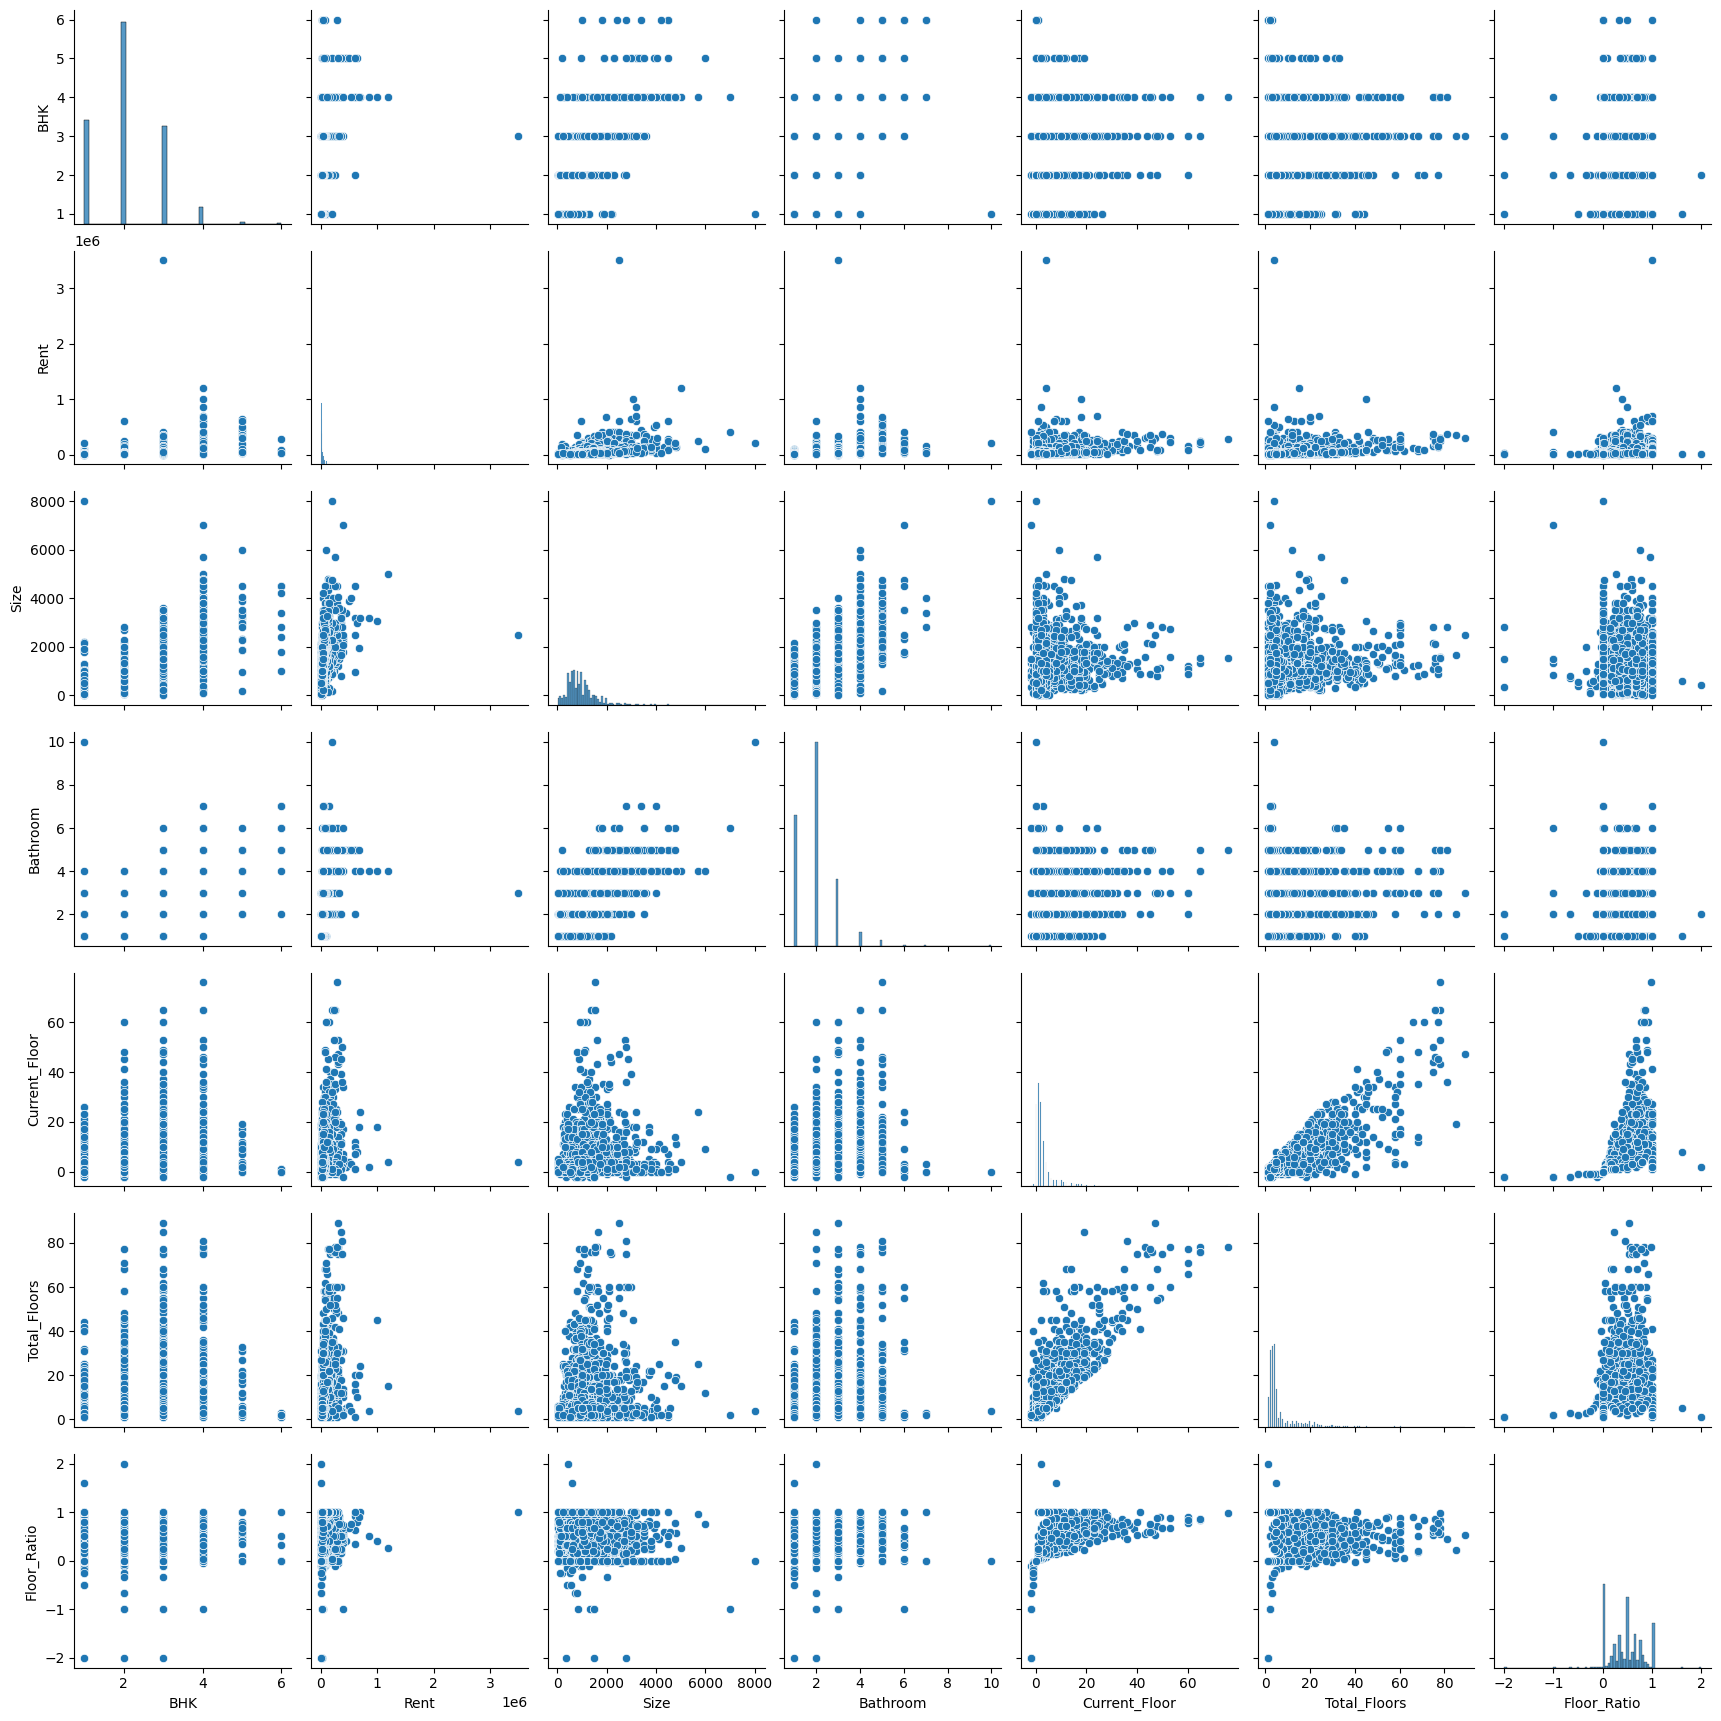

In [14]:
sns.pairplot(df)

In [15]:
def value_count(df):
    for var in df.columns:
        print(df[var].value_counts())
        print("------------------------------")

In [16]:
value_count(df)

BHK
2    2265
1    1167
3    1098
4     189
5      19
6       8
Name: count, dtype: int64
------------------------------
Rent
15000    275
10000    248
12000    238
20000    175
8000     162
        ... 
1200       1
5400       1
12333      1
21467      1
5800       1
Name: count, Length: 243, dtype: int64
------------------------------
Size
1000    240
600     225
800     220
1200    193
500     192
       ... 
67        1
1156      1
2671      1
2352      1
1606      1
Name: count, Length: 615, dtype: int64
------------------------------
Area Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64
------------------------------
Area Locality
Bandra West                       37
Gachibowli                        29
Electronic City                   24
Miyapur, NH 9                     22
Velachery                         22
                                  ..
Hoysala Nagar                      1
Nagarabhavi                        1
Shamanna Garden, 

<Axes: >

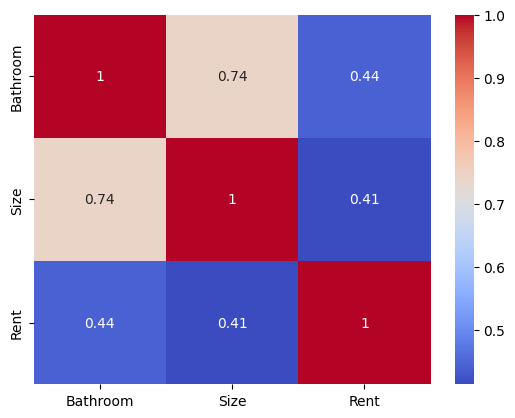

In [17]:
#correlation heatmap
num_var=['Bathroom', 'Size', 'Rent']
sns.heatmap(df[num_var].corr(), cmap="coolwarm", annot=True)

In [18]:
df['Size'].value_counts()

Size
1000    240
600     225
800     220
1200    193
500     192
       ... 
67        1
1156      1
2671      1
2352      1
1606      1
Name: count, Length: 615, dtype: int64

In [19]:
#machine learning model
#split dataset in train and test
x=df.drop('Rent', axis=1)
y=df['Rent']
print('shape of x=', x.shape)
print('shape of y=', y.shape)

shape of x= (4746, 12)
shape of y= (4746,)


In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2)
print('shape of x_train=', x_train.shape)
print('shape of y_train=', y_train.shape)
print('shape of x_test=', x_test.shape)
print('shape of y_test=', y_test.shape)

shape of x_train= (3796, 12)
shape of y_train= (3796,)
shape of x_test= (950, 12)
shape of y_test= (950,)


In [21]:
#machine learning modeltraining

#linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
lr=LinearRegression()
lr_lasso=Lasso()
lr_ridge=Ridge()

In [32]:
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(y_test, y_pred))

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
lr=LinearRegression()
lr_lasso=Lasso()
lr_ridge=Ridge()

def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(y_test, y_pred))

lr.fit(x_train, y_train)
lr_score = lr.score(x_test, y_test)
lr_rmse = rmse(y_test, lr.predict(x_test))

lr_score, lr_rmse


ValueError: could not convert string to float: 'Super Area'

In [28]:
print(df.dtypes)


BHK                    int64
Rent                   int64
Size                   int64
Area Type             object
Area Locality         object
City                  object
Furnishing Status     object
Tenant Preferred      object
Bathroom               int64
Point of Contact      object
Current_Floor          int64
Total_Floors           int64
Floor_Ratio          float64
dtype: object
